# Plot distribution of each summer metric for zonal buckets and also the distribution of the linear trends (slopes) for each

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

In [2]:
# read in all metrics
input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_ALL_summer_stats.nc'
ds_full = xr.open_dataset(input_path)


In [3]:
# read in trend files

# SummerLength
input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_LengthTrends.nc'
ds_length_trends = xr.open_dataset(input_path)

input_path2 = '../../../Data/ERA5-global/Analysis/New/1990-2023_LengthTrends.nc'
ds_length_trends_an = xr.open_dataset(input_path2)

# SummerStart
input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_StartTrends.nc'
ds_start_trends = xr.open_dataset(input_path)

input_path2 = '../../../Data/ERA5-global/Analysis/New/1990-2023_StartTrends.nc'
ds_start_trends_an = xr.open_dataset(input_path2)

# SummerEnd
input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_EndTrends.nc'
ds_end_trends = xr.open_dataset(input_path)

input_path2 = '../../../Data/ERA5-global/Analysis/New/1990-2023_EndTrends.nc'
ds_end_trends_an = xr.open_dataset(input_path2)

# SummerHeat
input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_AccHeatTrends.nc'
ds_heat_trends = xr.open_dataset(input_path)

input_path2 = '../../../Data/ERA5-global/Analysis/New/1990-2023_AccHeatTrends.nc'
ds_heat_trends_an = xr.open_dataset(input_path2)

# Mean Temp
input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_MeanTTrends.nc'
ds_meanT_trends = xr.open_dataset(input_path)

input_path2 = '../../../Data/ERA5-global/Analysis/New/1990-2023_MeanTTrends.nc'
ds_meanT_trends_an = xr.open_dataset(input_path2)

In [10]:
# generate weights for any spatial averages
# (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds_full.lat))
weights.name = "weights"

## Summer Length: Distribution of values and trends by latitude

In [6]:
# data for 1961-1990 Baseline period and 1990-2023 analysis period
length_base = ds_full.SummerLength.sel(time=slice('1961','1990'))
length_an = ds_full.SummerLength.sel(time=slice('1990','2023'))
#length_base, length_an

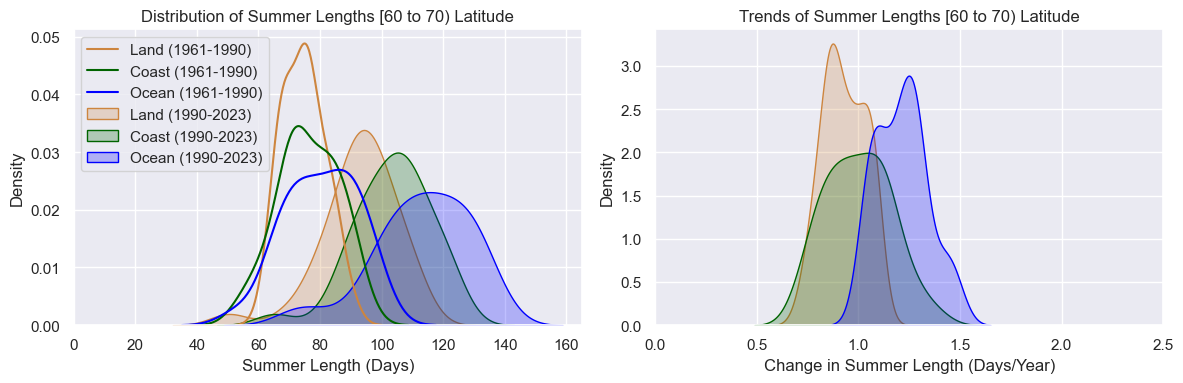

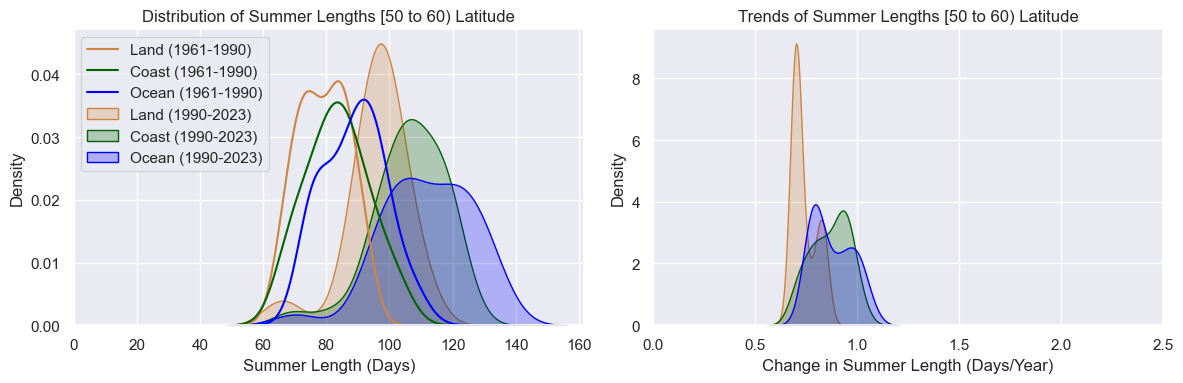

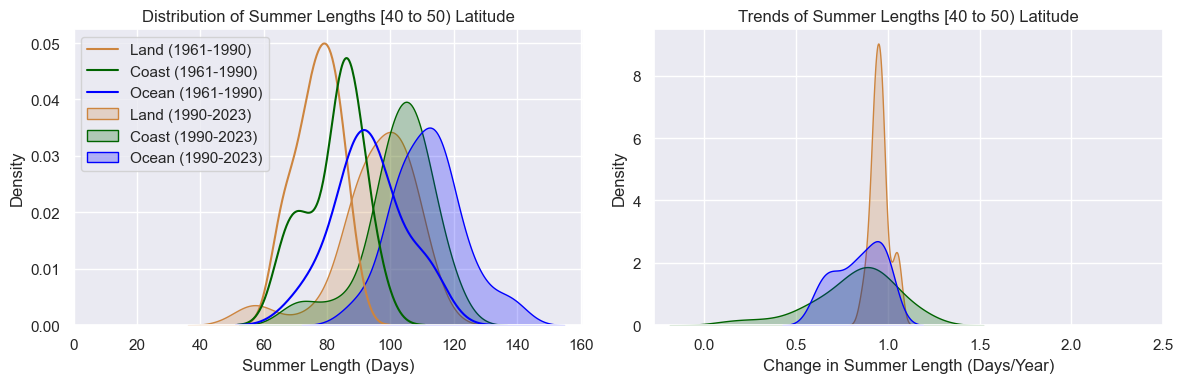

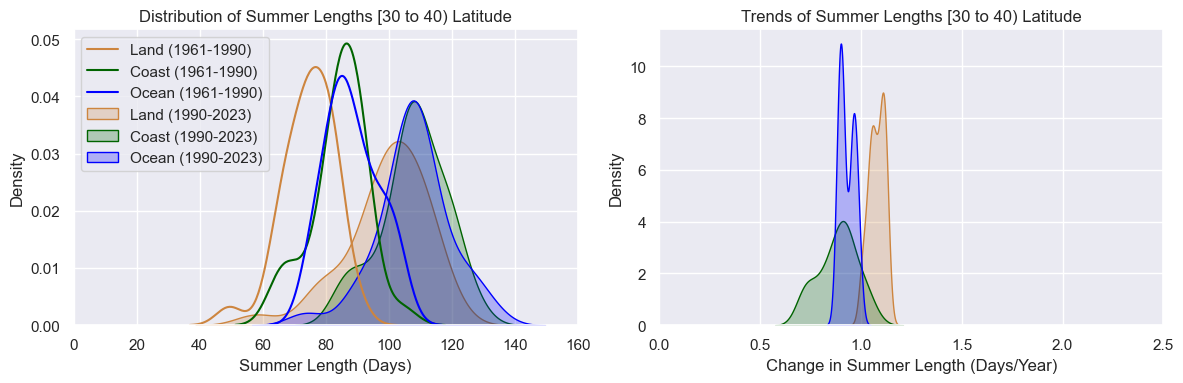

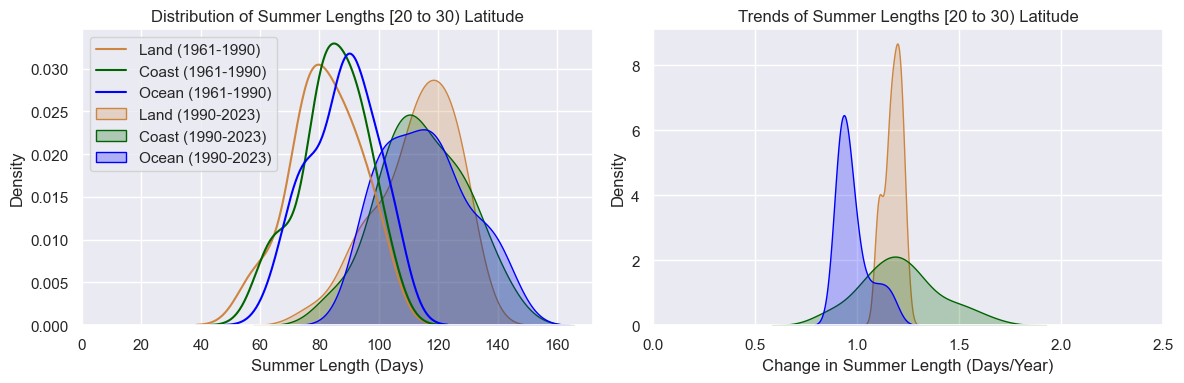

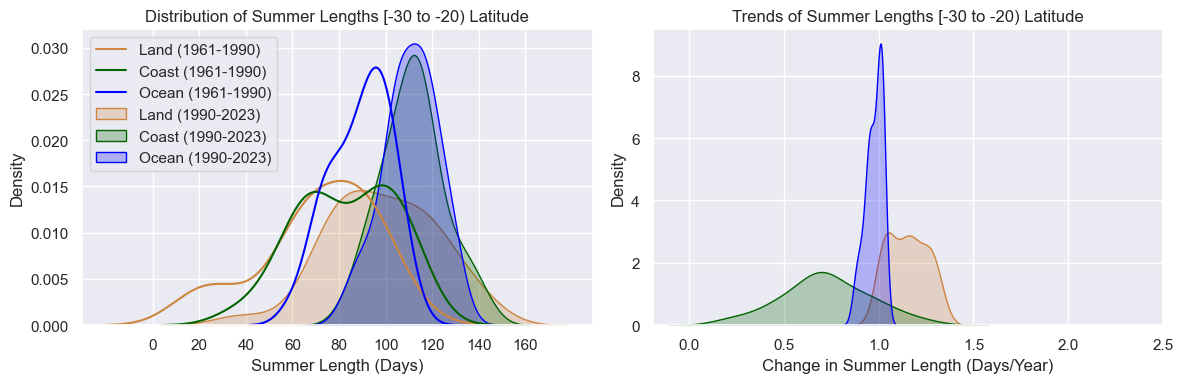

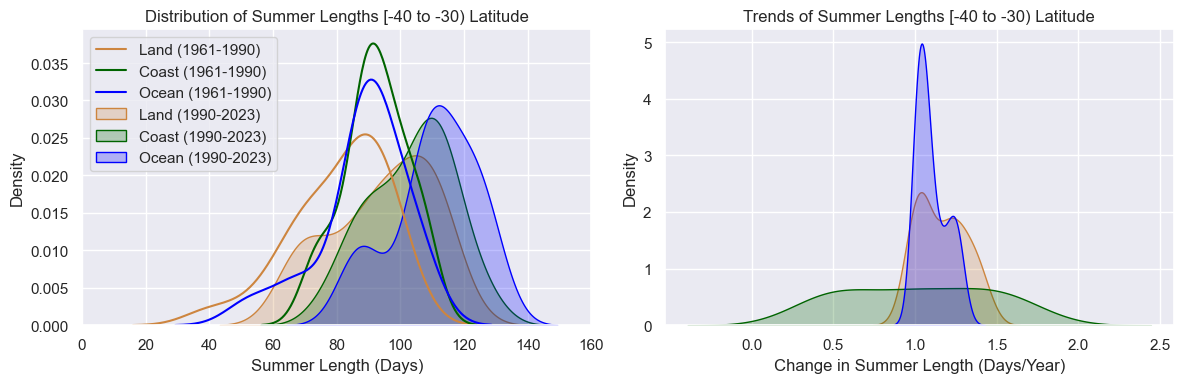

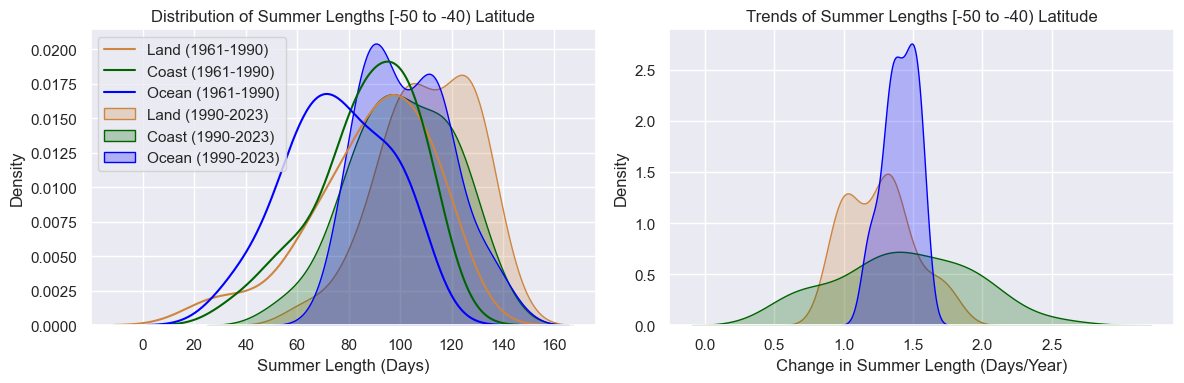

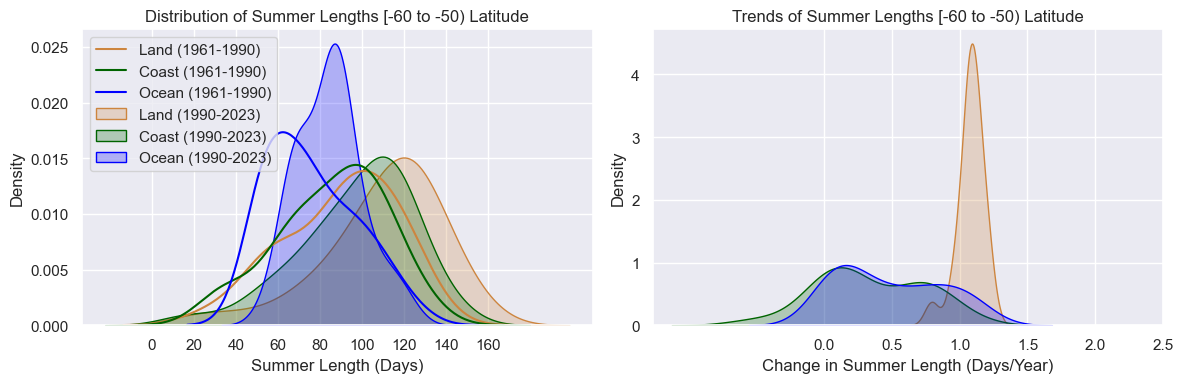

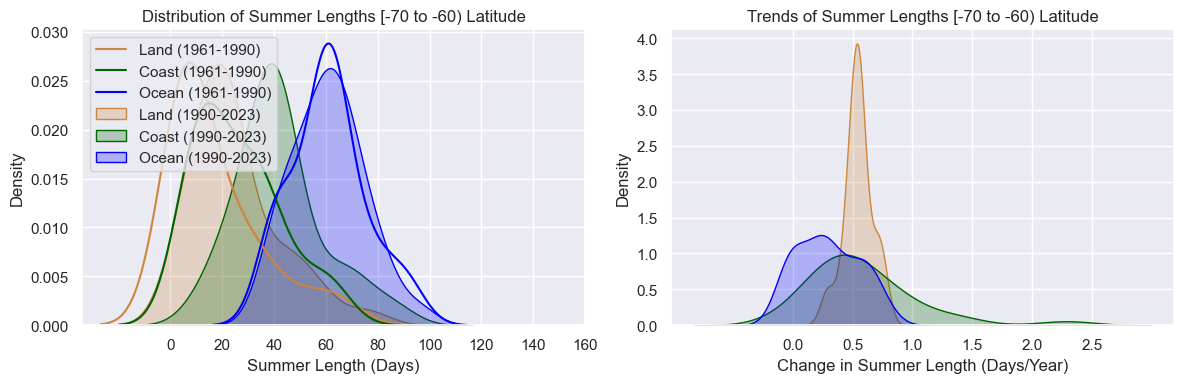

CPU times: user 9.97 s, sys: 4.56 s, total: 14.5 s
Wall time: 14.6 s


In [178]:
%%time

# plots by latitude bins - these are the lower end of 10 deg bins
lat_bins = [60,50,40,30,20,-30,-40,-50,-60,-70]

# levels for the kde plots
levels = 2

# one year of ds_full for extracting lsm and Coastal flags
# use mean to drop the time coordinate
ds_2023 = ds_full.sel(time=['2023']).mean(dim='time')
ds_2023['Coastal'] = ds_2023.Coastal.astype(bool)
#ds_coastal_2023 = ds_full.sel(time=['2023']).Coastal

# loop through all latitude buckets
for i,v in enumerate(lat_bins):

    # datasets of weighted averages for the midlatitudes for these lat buckets
    # for now, KEEPING grid cells from averages where the mean summer temp was 0 K meaning no summer
    land_base = ds_full.SummerLength.sel(time=slice('1961','1990')).where((ds_full.lsm > 0.5) & #(ds_full.SummerMeanT > 0) & 
                                                             (ds_full.Coastal == False) &
                                 ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
    
    coast_base = ds_full.SummerLength.sel(time=slice('1961','1990')).where((ds_full.Coastal) & #(ds_full.SummerMeanT > 0) &
                                  ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    ocean_base = ds_full.SummerLength.sel(time=slice('1961','1990')).where((ds_full.lsm <= 0.5) & #(ds_full.SummerMeanT > 0) &
                              ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    ocean_an = ds_full.SummerLength.sel(time=slice('1990','2023')).where((ds_full.lsm <= 0.5) & #(ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
        
    land_an = ds_full.SummerLength.sel(time=slice('1990','2023')).where((ds_full.lsm > 0.5) & #(ds_full.SummerMeanT > 0) & 
                                                           (ds_full.Coastal == False) &
                                                          ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    coast_an = ds_full.SummerLength.sel(time=slice('1990','2023')).where((ds_full.Coastal) & #(ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])


    # datasets of zonal trends for land, ocean, coasts during analysis period
    land_trends_an = ds_length_trends_an.LengthSlope.where((ds_2023.lsm > 0.5) & (ds_2023.Coastal == False) & 
                                             ((ds_length_trends_an.lat >= v) & 
                                              (ds_length_trends_an.lat < (v+10)))).mean(dim='lon')

    coast_trends_an = ds_length_trends_an.LengthSlope.where((ds_2023.Coastal) & 
                                             ((ds_length_trends_an.lat >= v) & 
                                              (ds_length_trends_an.lat < (v+10)))).mean(dim='lon')

    ocean_trends_an = ds_length_trends_an.LengthSlope.where((ds_2023.lsm <= 0.5) & 
                                         ((ds_length_trends_an.lat >= v) & 
                                          (ds_length_trends_an.lat < (v+10)))).mean(dim='lon')

    
    # create blank fig
    fig = plt.figure(figsize = (12,4))
    sns.set_theme(style="darkgrid")
    
    # Length value distributions
    #ax1 = fig.add_subplot(1,2,1)
    ax1 = fig.add_subplot(1,2,1)
    sns.kdeplot(land_base, fill=False, color="peru", label="Land (1961-1990)", levels=levels)
    sns.kdeplot(coast_base, fill=False, color="darkgreen", label="Coast (1961-1990)", levels=levels)
    sns.kdeplot(ocean_base, fill=False, color="blue", label="Ocean (1961-1990)", levels=levels)
    sns.kdeplot(land_an, fill=True, color="peru", label="Land (1990-2023)", levels=levels)
    sns.kdeplot(coast_an, fill=True, color="darkgreen", label="Coast (1990-2023)", levels=levels)
    sns.kdeplot(ocean_an, fill=True, color="blue", label="Ocean (1990-2023)", levels=levels)
    ax1.set_title("Distribution of Summer Lengths [" + str(v) +" to " + str(v+10) + ") Latitude")
    ax1.legend(loc='upper left')
    ax1.set_xticks(np.arange(0,180,20))
    ax1.set_xlabel("Summer Length (Days)")

    # Length trend distributions
    ax2 = fig.add_subplot(1,2,2)
    sns.kdeplot(land_trends_an, fill=True, color="peru", label="Land (1990-2023)", levels=levels)
    sns.kdeplot(coast_trends_an, fill=True, color="darkgreen", label="Coast (1990-2023)", levels=levels)
    sns.kdeplot(ocean_trends_an, fill=True, color="blue", label="Ocean (1990-2023)", levels=levels)
    ax2.set_title("Trends of Summer Lengths [" + str(v) +" to " + str(v+10) + ") Latitude")
    #ax2.legend(loc='upper left')
    ax2.set_xticks(np.arange(0,3,0.5))
    ax2.set_xlabel("Change in Summer Length (Days/Year)")

    plt.tight_layout()
    plt.show()

### Boxplots instead of density for the trends

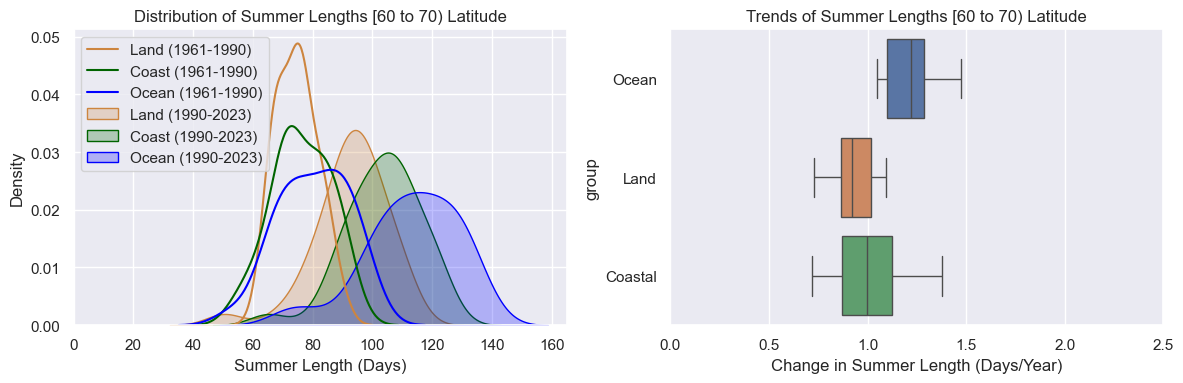

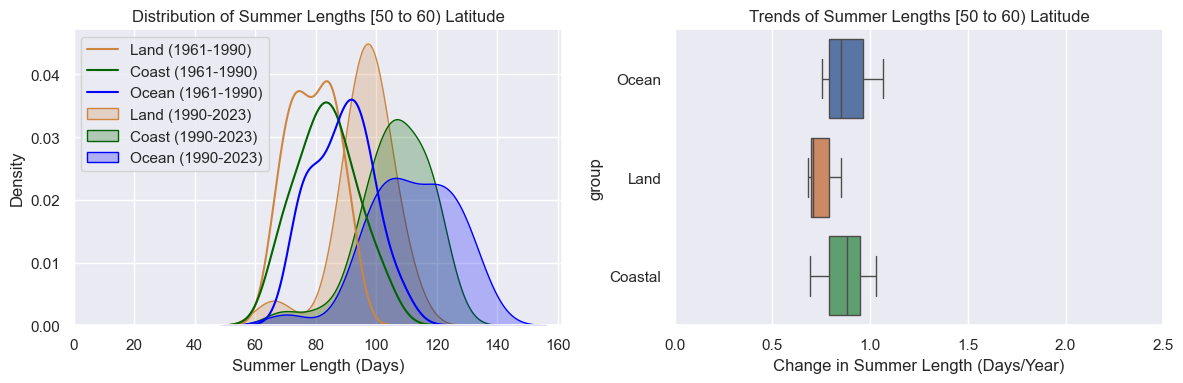

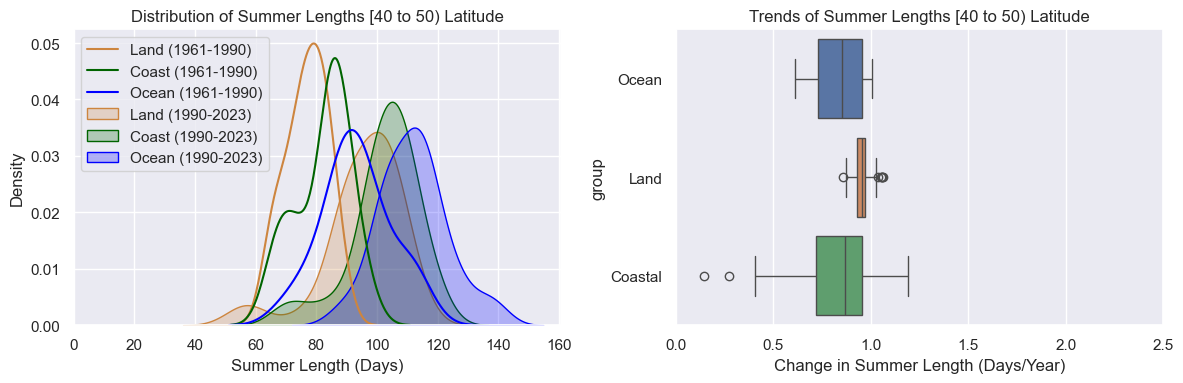

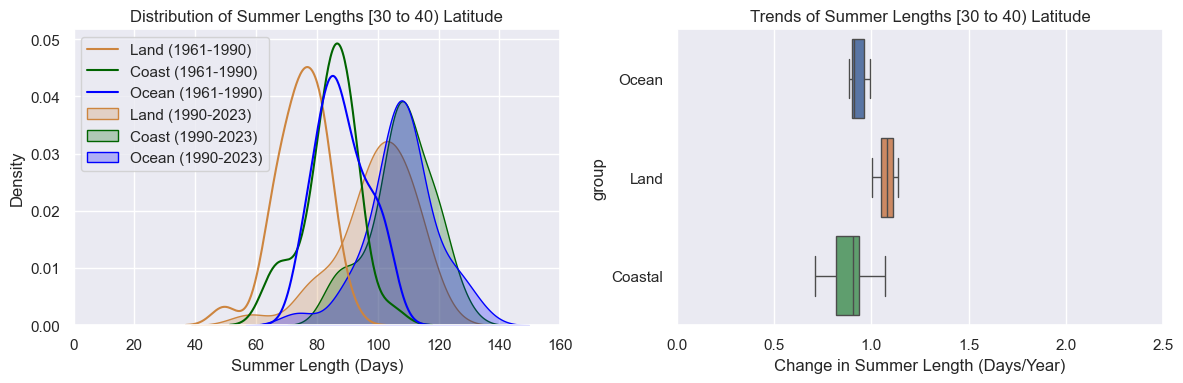

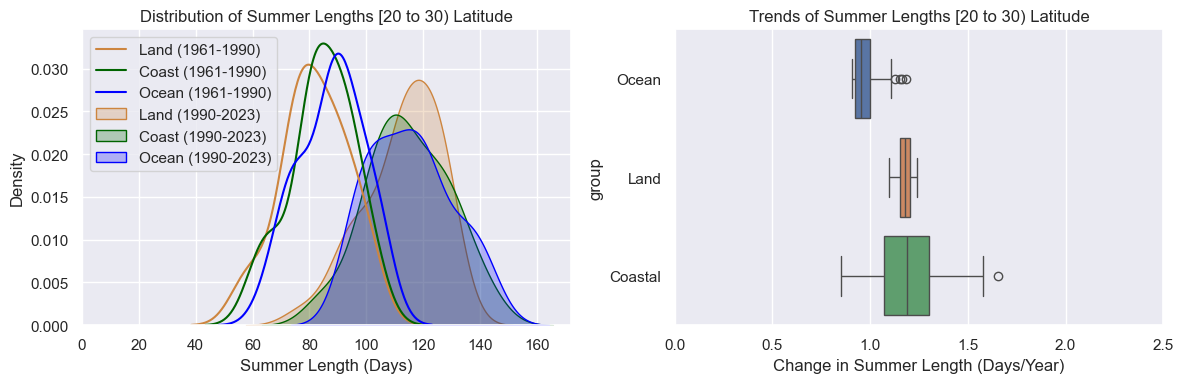

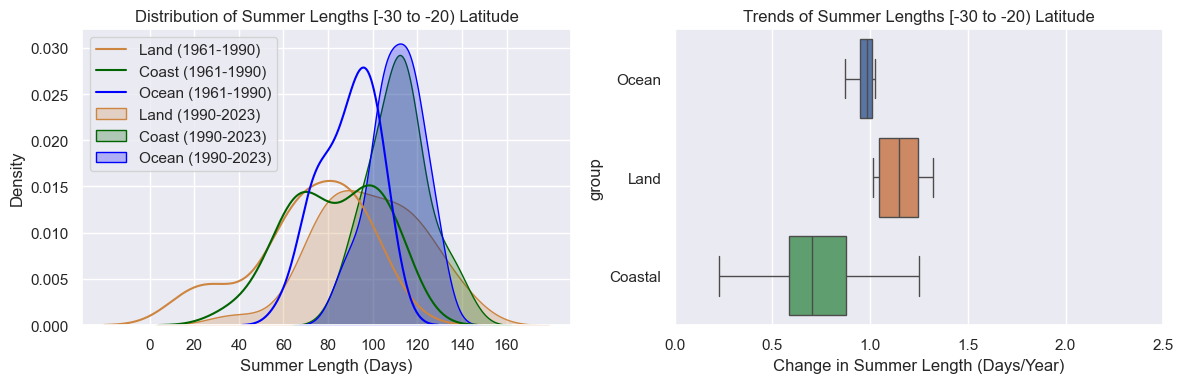

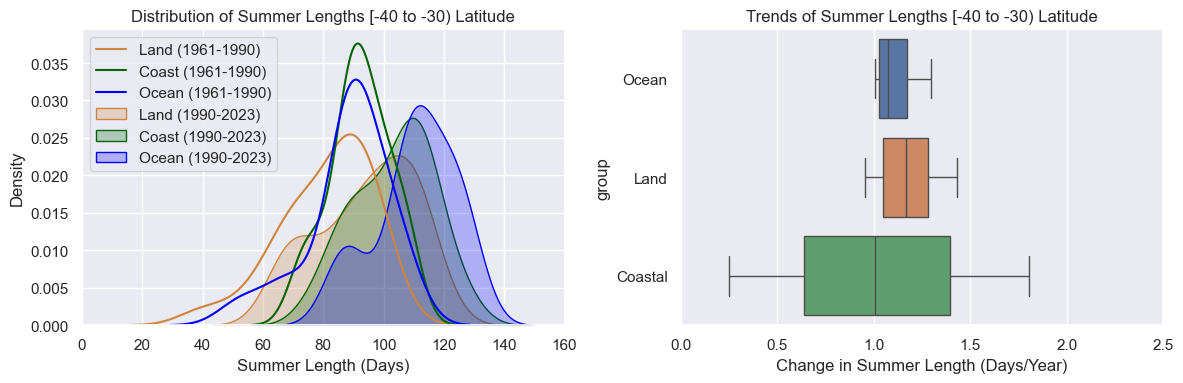

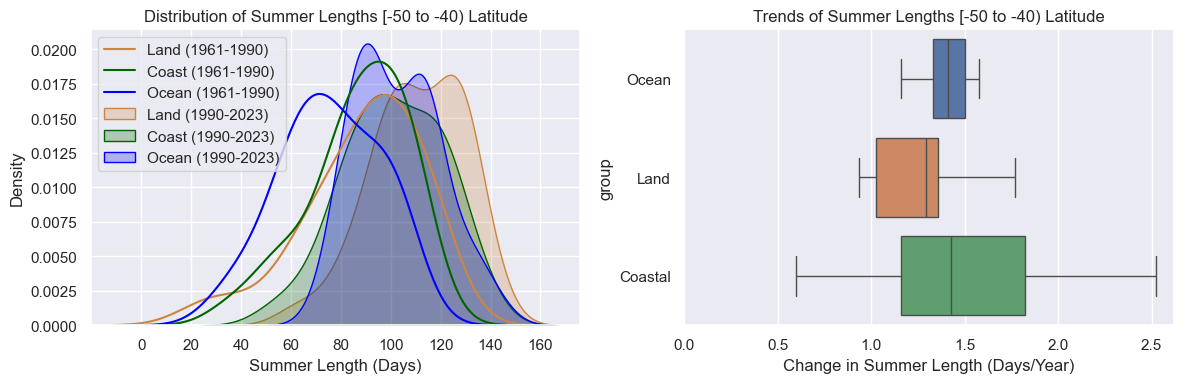

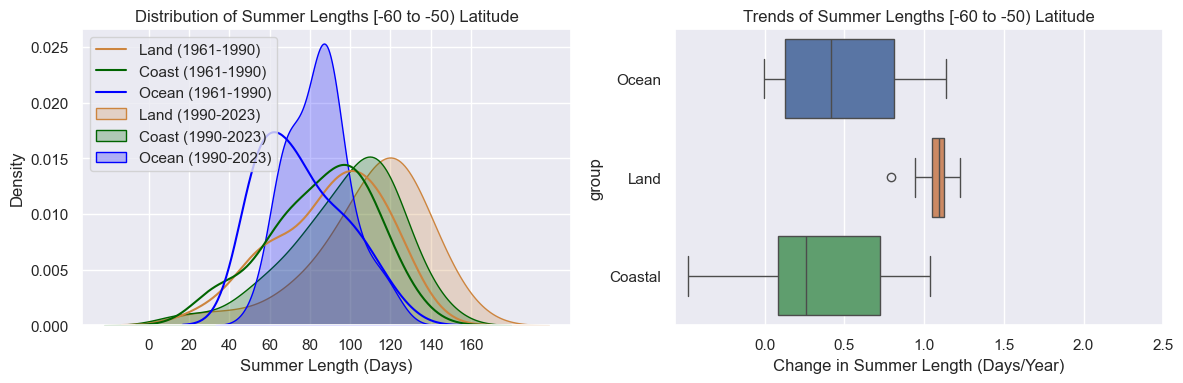

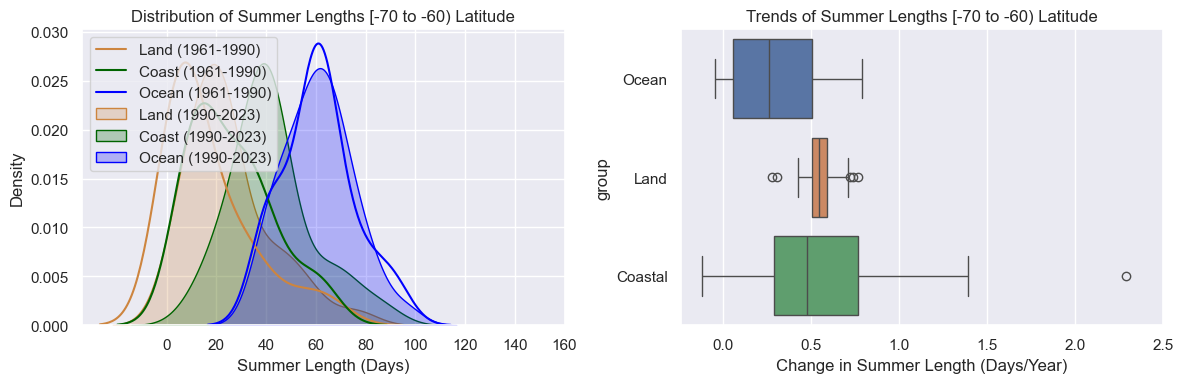

CPU times: user 9.89 s, sys: 4.54 s, total: 14.4 s
Wall time: 14.4 s


In [179]:
%%time


# loop through all latitude buckets
for i,v in enumerate(lat_bins):

    # datasets of weighted averages for the midlatitudes for these lat buckets
    # for now, KEEPING grid cells from averages where the mean summer temp was 0 K meaning no summer
    land_base = ds_full.SummerLength.sel(time=slice('1961','1990')).where((ds_full.lsm > 0.5) & #(ds_full.SummerMeanT > 0) & 
                                                             (ds_full.Coastal == False) &
                                 ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
    
    coast_base = ds_full.SummerLength.sel(time=slice('1961','1990')).where((ds_full.Coastal) & #(ds_full.SummerMeanT > 0) &
                                  ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    ocean_base = ds_full.SummerLength.sel(time=slice('1961','1990')).where((ds_full.lsm <= 0.5) & #(ds_full.SummerMeanT > 0) &
                              ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    ocean_an = ds_full.SummerLength.sel(time=slice('1990','2023')).where((ds_full.lsm <= 0.5) & #(ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
        
    land_an = ds_full.SummerLength.sel(time=slice('1990','2023')).where((ds_full.lsm > 0.5) & #(ds_full.SummerMeanT > 0) & 
                                                           (ds_full.Coastal == False) &
                                                          ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    coast_an = ds_full.SummerLength.sel(time=slice('1990','2023')).where((ds_full.Coastal) & #(ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])


    # datasets of zonal trends for land, ocean, coasts during analysis period
    land_trends_an = ds_length_trends_an.LengthSlope.where((ds_2023.lsm > 0.5) & (ds_2023.Coastal == False) & 
                                             ((ds_length_trends_an.lat >= v) & 
                                              (ds_length_trends_an.lat < (v+10)))).mean(dim='lon')

    coast_trends_an = ds_length_trends_an.LengthSlope.where((ds_2023.Coastal) & 
                                             ((ds_length_trends_an.lat >= v) & 
                                              (ds_length_trends_an.lat < (v+10)))).mean(dim='lon')

    ocean_trends_an = ds_length_trends_an.LengthSlope.where((ds_2023.lsm <= 0.5) & 
                                         ((ds_length_trends_an.lat >= v) & 
                                          (ds_length_trends_an.lat < (v+10)))).mean(dim='lon')

    
    # create blank fig
    fig = plt.figure(figsize = (12,4))
    sns.set_theme(style="darkgrid")
    
    # Length value distributions
    #ax1 = fig.add_subplot(1,2,1)
    ax1 = fig.add_subplot(1,2,1)
    sns.kdeplot(land_base, fill=False, color="peru", label="Land (1961-1990)", levels=levels)
    sns.kdeplot(coast_base, fill=False, color="darkgreen", label="Coast (1961-1990)", levels=levels)
    sns.kdeplot(ocean_base, fill=False, color="blue", label="Ocean (1961-1990)", levels=levels)
    sns.kdeplot(land_an, fill=True, color="peru", label="Land (1990-2023)", levels=levels)
    sns.kdeplot(coast_an, fill=True, color="darkgreen", label="Coast (1990-2023)", levels=levels)
    sns.kdeplot(ocean_an, fill=True, color="blue", label="Ocean (1990-2023)", levels=levels)
    ax1.set_title("Distribution of Summer Lengths [" + str(v) +" to " + str(v+10) + ") Latitude")
    ax1.legend(loc='upper left')
    ax1.set_xticks(np.arange(0,180,20))
    ax1.set_xlabel("Summer Length (Days)")

    # Length trend distributions
    ax2 = fig.add_subplot(1,2,2)
    a = pd.DataFrame({ 'group' : np.repeat('Land', len(land_trends_an.values)), 'value': land_trends_an.values })
    b = pd.DataFrame({ 'group' : np.repeat('Coastal', len(land_trends_an.values)), 'value': coast_trends_an.values })
    c = pd.DataFrame({ 'group' : np.repeat('Ocean', len(land_trends_an.values)), 'value': ocean_trends_an.values })
    df = pd.concat([c,a,b], ignore_index=True)
    # plot boxplot 
    sns.boxplot( x='value', y='group', data=df, hue='group')
    ax2.set_title("Trends of Summer Lengths [" + str(v) +" to " + str(v+10) + ") Latitude")
    #ax2.legend(loc='upper left')
    ax2.set_xticks(np.arange(0,3,0.5))
    ax2.set_xlabel("Change in Summer Length (Days/Year)")

    plt.tight_layout()
    plt.show()

## Summer Heat: Distribution of values and trends by latitude

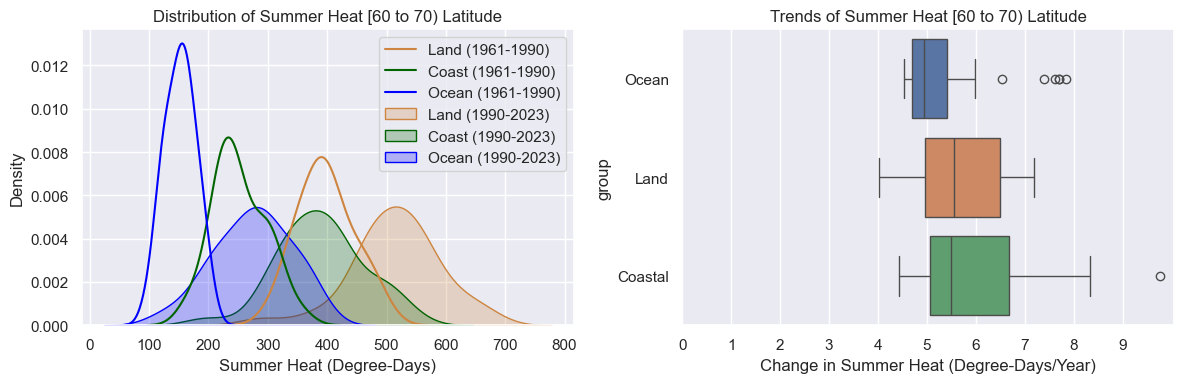

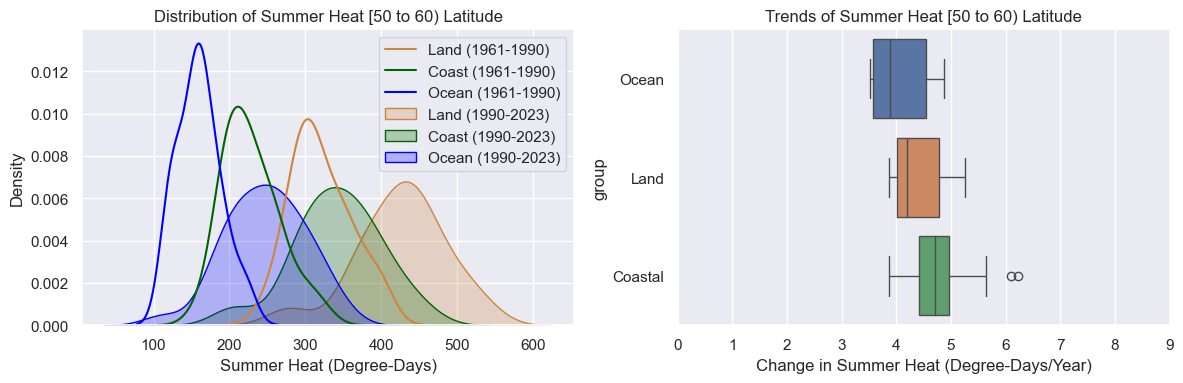

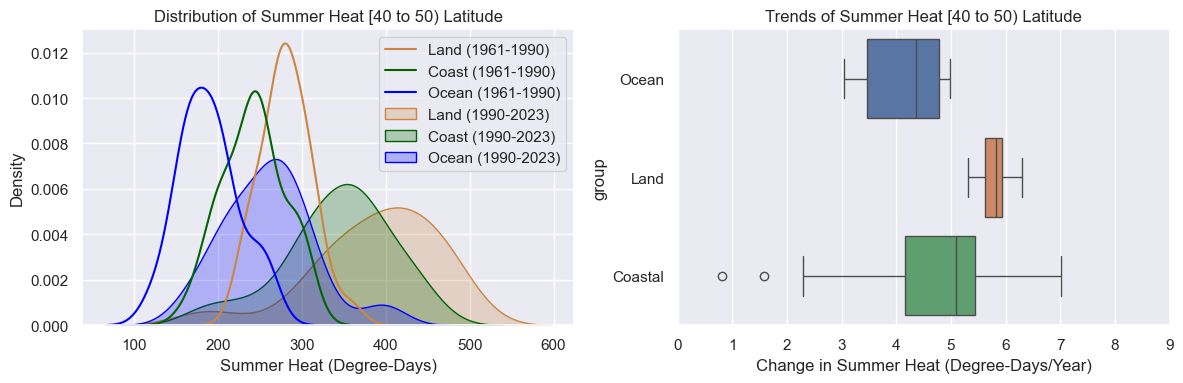

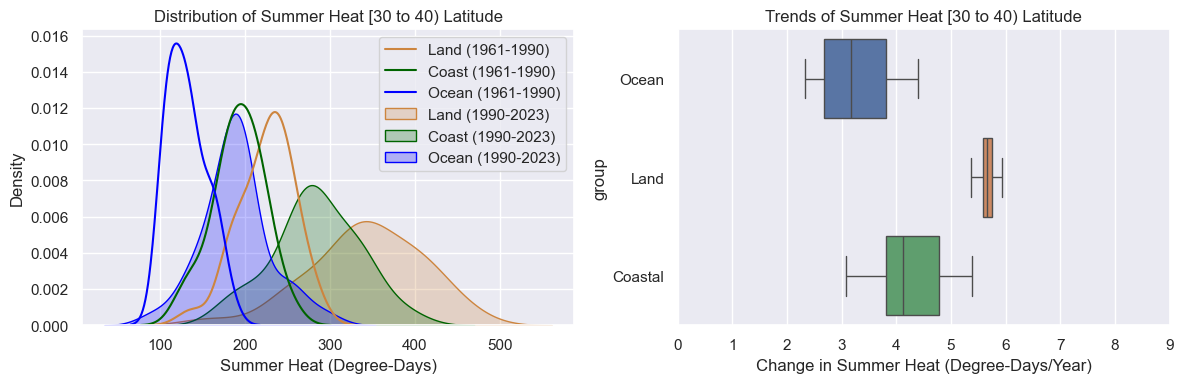

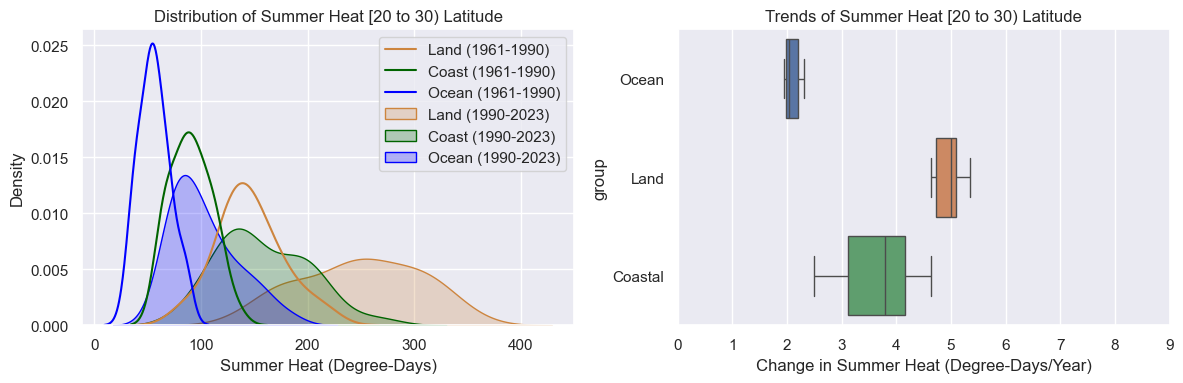

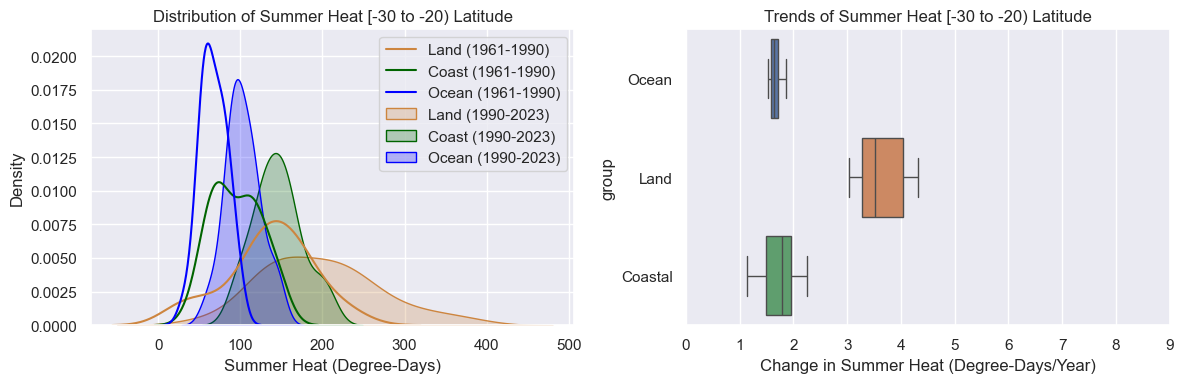

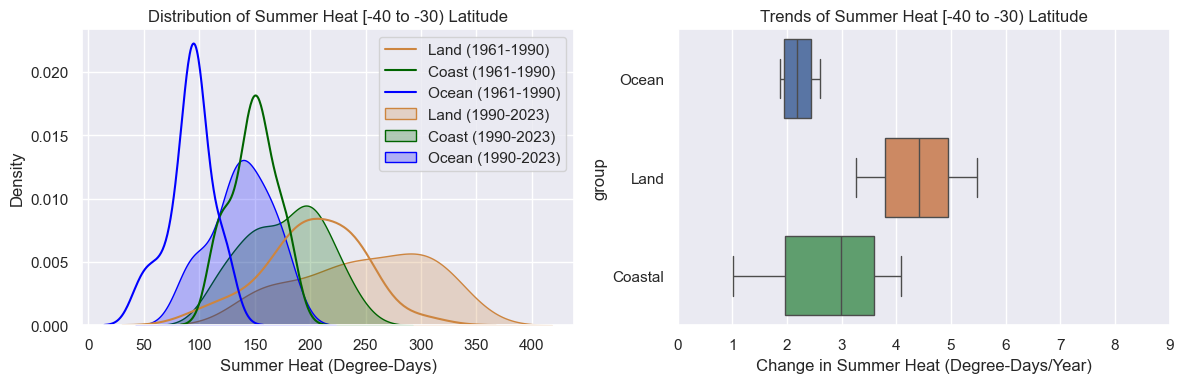

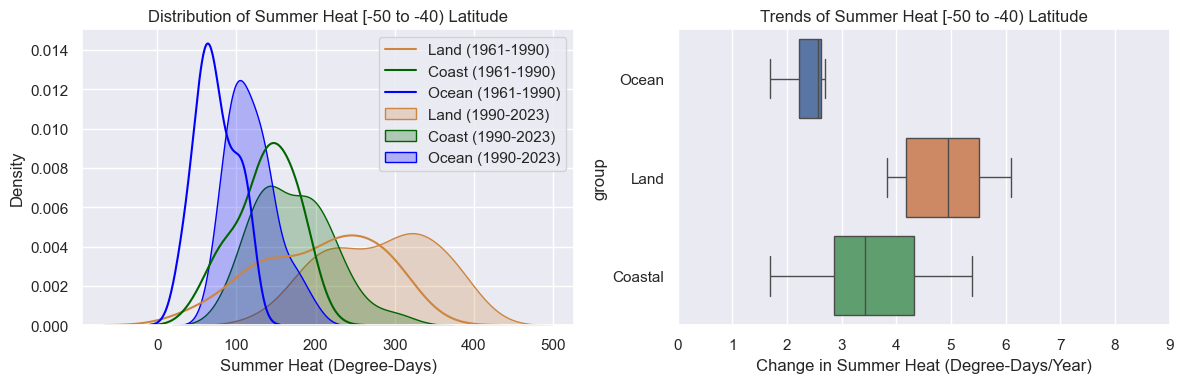

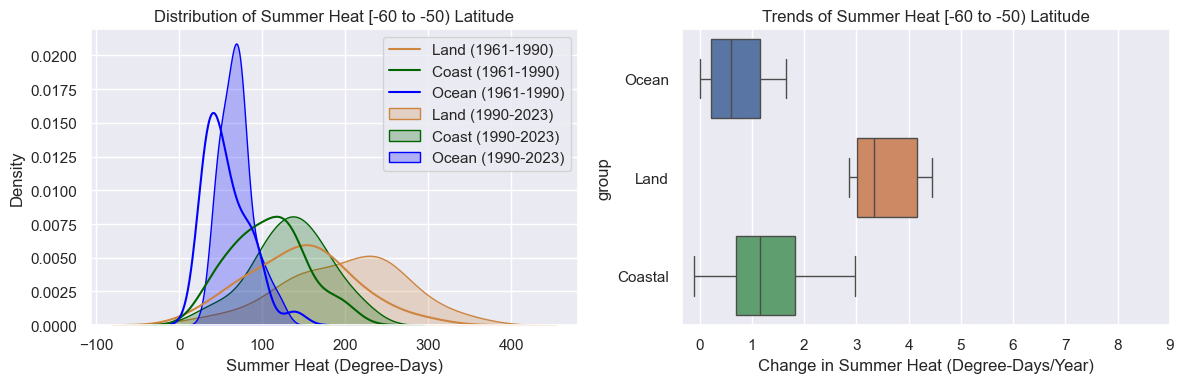

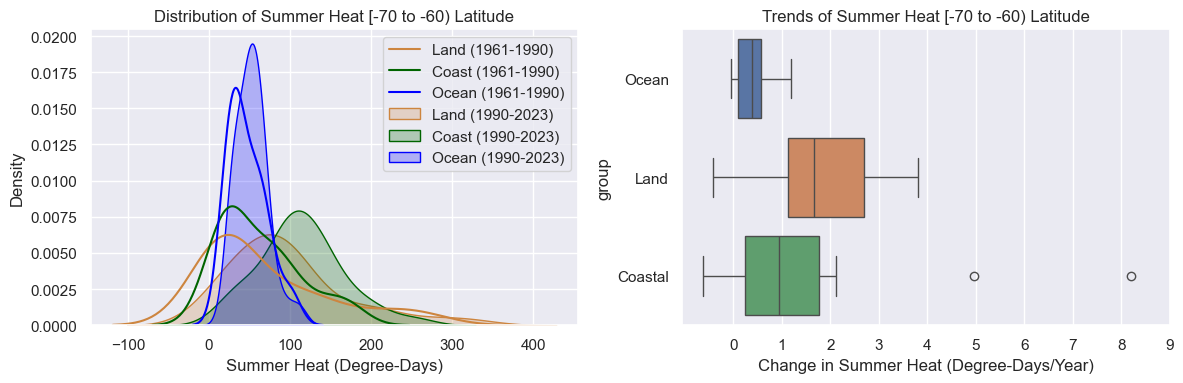

CPU times: user 10 s, sys: 4.64 s, total: 14.7 s
Wall time: 14.6 s


In [180]:
%%time

# plots by latitude bins - these are the lower end of 10 deg bins
lat_bins = [60,50,40,30,20,-30,-40,-50,-60,-70]

# levels for the kde plots
levels = 2

# one year of ds_full for extracting lsm and Coastal flags
# use mean to drop the time coordinate
ds_2023 = ds_full.sel(time=['2023']).mean(dim='time')
ds_2023['Coastal'] = ds_2023.Coastal.astype(bool)
#ds_coastal_2023 = ds_full.sel(time=['2023']).Coastal

# loop through all latitude buckets
for i,v in enumerate(lat_bins):

    # datasets of weighted averages for the midlatitudes for these lat buckets
    # for now, KEEPING grid cells from averages where the mean summer temp was 0 K meaning no summer
    land_base = ds_full.SummerHeat.sel(time=slice('1961','1990')).where((ds_full.lsm > 0.5) & #(ds_full.SummerMeanT > 0) & 
                                                             (ds_full.Coastal == False) &
                                 ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
    
    coast_base = ds_full.SummerHeat.sel(time=slice('1961','1990')).where((ds_full.Coastal) & #(ds_full.SummerMeanT > 0) &
                                  ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    ocean_base = ds_full.SummerHeat.sel(time=slice('1961','1990')).where((ds_full.lsm <= 0.5) & #(ds_full.SummerMeanT > 0) &
                              ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    ocean_an = ds_full.SummerHeat.sel(time=slice('1990','2023')).where((ds_full.lsm <= 0.5) & #(ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
        
    land_an = ds_full.SummerHeat.sel(time=slice('1990','2023')).where((ds_full.lsm > 0.5) & #(ds_full.SummerMeanT > 0) & 
                                                           (ds_full.Coastal == False) &
                                                          ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    coast_an = ds_full.SummerHeat.sel(time=slice('1990','2023')).where((ds_full.Coastal) & #(ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])


    # datasets of zonal trends for land, ocean, coasts during analysis period
    land_trends_an = ds_heat_trends_an.HeatSlope.where((ds_2023.lsm > 0.5) & (ds_2023.Coastal == False) & 
                                             ((ds_heat_trends_an.lat >= v) & 
                                              (ds_heat_trends_an.lat < (v+10)))).mean(dim='lon')

    coast_trends_an = ds_heat_trends_an.HeatSlope.where((ds_2023.Coastal) & 
                                             ((ds_heat_trends_an.lat >= v) & 
                                              (ds_heat_trends_an.lat < (v+10)))).mean(dim='lon')

    ocean_trends_an = ds_heat_trends_an.HeatSlope.where((ds_2023.lsm <= 0.5) & 
                                         ((ds_heat_trends_an.lat >= v) & 
                                          (ds_heat_trends_an.lat < (v+10)))).mean(dim='lon')

    
    # create blank fig
    fig = plt.figure(figsize = (12,4))
    sns.set_theme(style="darkgrid")
    
    # Heat value distributions
    #ax1 = fig.add_subplot(1,2,1)
    ax1 = fig.add_subplot(1,2,1)
    sns.kdeplot(land_base, fill=False, color="peru", label="Land (1961-1990)", levels=levels)
    sns.kdeplot(coast_base, fill=False, color="darkgreen", label="Coast (1961-1990)", levels=levels)
    sns.kdeplot(ocean_base, fill=False, color="blue", label="Ocean (1961-1990)", levels=levels)
    sns.kdeplot(land_an, fill=True, color="peru", label="Land (1990-2023)", levels=levels)
    sns.kdeplot(coast_an, fill=True, color="darkgreen", label="Coast (1990-2023)", levels=levels)
    sns.kdeplot(ocean_an, fill=True, color="blue", label="Ocean (1990-2023)", levels=levels)
    ax1.set_title("Distribution of Summer Heat [" + str(v) +" to " + str(v+10) + ") Latitude")
    ax1.legend(loc='upper right')
    #ax1.set_xticks(np.arange(0,180,20))
    ax1.set_xlabel("Summer Heat (Degree-Days)")

    # Heat trend distributions
    # got rid of an error about duplicate indexes via
    # https://stackoverflow.com/questions/27236275/what-does-valueerror-cannot-reindex-from-a-duplicate-axis-mean
    
    ax2 = fig.add_subplot(1,2,2)
    # sns.kdeplot(land_trends_an, fill=True, color="brown", label="Land (1990-2023)", levels=levels)
    # sns.kdeplot(coast_trends_an, fill=True, color="darkgreen", label="Coast (1990-2023)", levels=levels)
    # sns.kdeplot(ocean_trends_an, fill=True, color="blue", label="Ocean (1990-2023)", levels=levels)

    #colors = ['brown', 'darkgreen', 'blue']
    # Dataset:
    a = pd.DataFrame({ 'group' : np.repeat('Land', len(land_trends_an.values)), 'value': land_trends_an.values })
    b = pd.DataFrame({ 'group' : np.repeat('Coastal', len(land_trends_an.values)), 'value': coast_trends_an.values })
    c = pd.DataFrame({ 'group' : np.repeat('Ocean', len(land_trends_an.values)), 'value': ocean_trends_an.values })
    df = pd.concat([c,a,b], ignore_index=True)

    # Calculate number of obs per group & median to position labels
    ####
    # for this to work need to count the grid cells in each classification before aggregating by longitude
    ####
    # medians = df.groupby(['group'])['value'].median().values
    # nobs = (~np.isnan(df.groupby("group")).to_numpy()).sum()

    # #(~np.isnan(pd.DataFrame({'a':[1,2,np.nan]}).to_numpy())).sum()
    
    # nobs = [str(x) for x in nobs.tolist()]
    # nobs = ["n: " + i for i in nobs]
    # print(nobs)
     
    # Add it to the plot
    #pos = range(len(nobs))
    # for tick,label in zip(pos,ax.get_xticklabels()):
    #     plt.text(pos[tick], medians[tick] + 0.4, nobs[tick], horizontalalignment='center', size='medium', color='w', weight='semibold')
      
    # plot boxplot 
    sns.boxplot( x='value', y='group', data=df, hue='group')  
    ax2.set_title("Trends of Summer Heat [" + str(v) +" to " + str(v+10) + ") Latitude")
    #ax2.legend(loc='upper left')
    ax2.set_xticks(np.arange(0,10,1))
    ax2.set_xlabel("Change in Summer Heat (Degree-Days/Year)")

    plt.tight_layout()
    plt.show()

In [142]:
(~np.isnan(pd.DataFrame({'a':[1,2,np.nan]}).to_numpy())).sum()

np.int64(2)

In [166]:
#https://stackoverflow.com/questions/15002085/how-to-get-values-from-a-cell-of-a-groupby-object
medians = df.groupby(['group'])['value'].median().values
#nobs = (~np.isnan(df.groupby("group")).to_numpy()).sum()
#nobs = ((df.groupby("group")).to_numpy()).sum()
nobs = df.groupby("group").get_group("Coastal")["value"].count()  #.size()#.values
nobs

np.int64(40)

group
Coastal    Axes(0.125,0.11;0.775x0.77)
Land       Axes(0.125,0.11;0.775x0.77)
Ocean      Axes(0.125,0.11;0.775x0.77)
Name: value, dtype: object

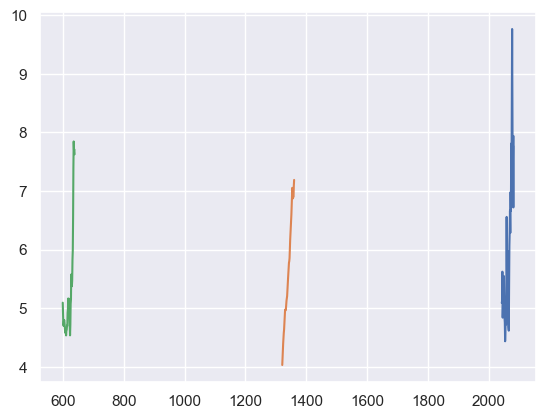

In [161]:
df.groupby("group")['value'].plot()

In [172]:
v=30
np.count_nonzero(~np.isnan(ds_heat_trends_an.HeatSlope.where((ds_2023.lsm <= 0.5) & 
                                         ((ds_heat_trends_an.lat >= v) & 
                                          (ds_heat_trends_an.lat < (v+10)))))), np.count_nonzero(~np.isnan(ds_heat_trends_an.HeatSlope.where((ds_2023.lsm > 0.5) & 
                                         ((ds_heat_trends_an.lat >= v) & 
                                          (ds_heat_trends_an.lat < (v+10)))))), np.count_nonzero(~np.isnan(ds_heat_trends_an.HeatSlope.where((ds_2023.Coastal) & 
                                         ((ds_heat_trends_an.lat >= v) & 
                                          (ds_heat_trends_an.lat < (v+10))))))


(33207, 24393, 1091)